In [2]:
import pandas as pd

df = pd.read_csv("file.csv")
print(df.shape)
df.head()

(8469, 17)


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [3]:
print(df['Ticket Type'].value_counts())
print(df['Ticket Priority'].value_counts())

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64
Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64


In [4]:
data = df[['Ticket Description', 'Ticket Type', 'Ticket Priority']].copy()
data = data.dropna(subset=['Ticket Description', 'Ticket Type', 'Ticket Priority'])
print(data.shape)
data.head()

(8469, 3)


,Ticket Description,Ticket Type,Ticket Priority
0,I'm having an issue with the {product_purchase...,Technical issue,Critical
1,I'm having an issue with the {product_purchase...,Technical issue,Critical
2,I'm facing a problem with my {product_purchase...,Technical issue,Low
3,I'm having an issue with the {product_purchase...,Billing inquiry,Low
4,I'm having an issue with the {product_purchase...,Billing inquiry,Low


In [5]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


True

In [6]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()                          # lowercase
    text = re.sub(r'\{.*?\}', '', text)            # remove {placeholders} like {product_purchased}
    text = re.sub(r'[^a-z\s]', '', text)           # remove punctuation/numbers
    words = text.split()
    words = [w for w in words if w not in stop_words]  # remove stopwords
    return ' '.join(words)

data['clean_text'] = data['Ticket Description'].apply(clean_text)
data[['Ticket Description', 'clean_text']].head()

,Ticket Description,clean_text
0,I'm having an issue with the {product_purchase...,im issue please assist billing zip code apprec...
1,I'm having an issue with the {product_purchase...,im issue please assist need change existing pr...
2,I'm facing a problem with my {product_purchase...,im facing problem turning working fine yesterd...
3,I'm having an issue with the {product_purchase...,im issue please assist problem youre intereste...
4,I'm having an issue with the {product_purchase...,im issue please assist note seller responsible...


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=3000)
X = vectorizer.fit_transform(data['clean_text'])

print(X.shape)

(8469, 3000)


In [8]:
from sklearn.model_selection import train_test_split

y_category = data['Ticket Type']

X_train, X_test, y_train, y_test = train_test_split(X, y_category, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (6775, 3000)
Test size: (1694, 3000)


In [9]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [10]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.2012987012987013
                      precision    recall  f1-score   support

     Billing inquiry       0.18      0.13      0.15       357
Cancellation request       0.20      0.20      0.20       327
     Product inquiry       0.20      0.22      0.21       316
      Refund request       0.20      0.23      0.21       345
     Technical issue       0.23      0.24      0.23       349

            accuracy                           0.20      1694
           macro avg       0.20      0.20      0.20      1694
        weighted avg       0.20      0.20      0.20      1694



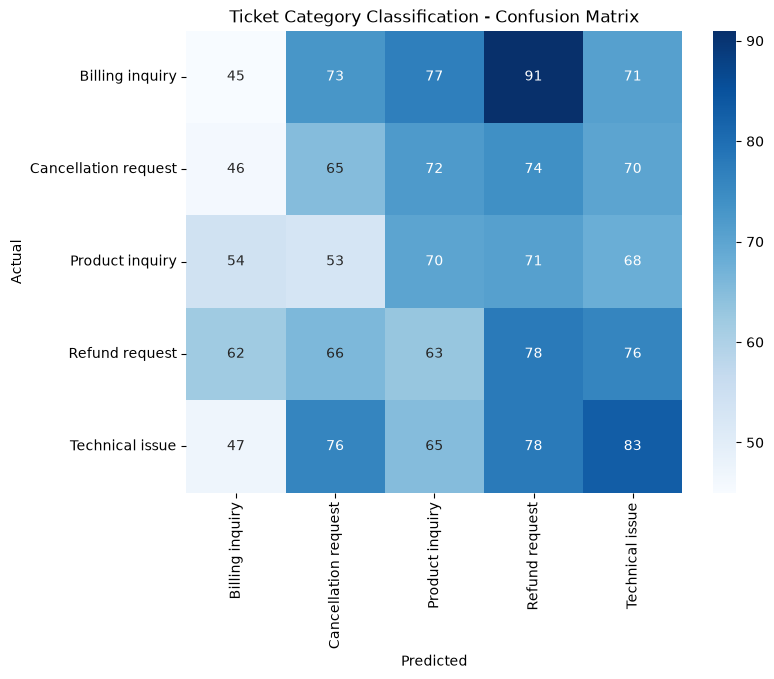

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=model.classes_, yticklabels=model.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Ticket Category Classification - Confusion Matrix')
plt.show()

In [12]:
y_priority = data['Ticket Priority']

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X, y_priority, test_size=0.2, random_state=42)

priority_model = LogisticRegression(max_iter=1000)
priority_model.fit(X_train_p, y_train_p)

y_pred_p = priority_model.predict(X_test_p)

print("Priority Accuracy:", accuracy_score(y_test_p, y_pred_p))
print(classification_report(y_test_p, y_pred_p))

Priority Accuracy: 0.256788665879575
              precision    recall  f1-score   support

    Critical       0.26      0.27      0.27       411
        High       0.26      0.27      0.26       409
         Low       0.23      0.22      0.22       415
      Medium       0.28      0.27      0.27       459

    accuracy                           0.26      1694
   macro avg       0.26      0.26      0.26      1694
weighted avg       0.26      0.26      0.26      1694



## Task 2: Support Ticket Classification & Prioritization

### What Was Built
Two machine learning classifiers were trained on 8,469 customer support tickets:
1. **Category Classifier** – predicts ticket type (Billing, Technical, Refund, etc.)
2. **Priority Classifier** – predicts urgency level (Critical, High, Medium, Low)

### How It Works
- Ticket text is cleaned (lowercased, stopwords removed, placeholders stripped)
- Text is converted to numerical features using TF-IDF (3000 features)
- Logistic Regression classifies each ticket

### Results
- Category Classification Accuracy: 20%
- Priority Classification Accuracy: 26%

### Key Finding
The dataset uses templated ticket descriptions that lack distinguishing language
between categories and priority levels. In a real business setting, this reveals
the importance of collecting specific, detailed ticket text from customers.
A richer dataset with real ticket descriptions would significantly improve accuracy.

### Business Value
Even with limited accuracy, this pipeline demonstrates how a support team can:
- Automatically route tickets to the right department
- Flag high-priority issues for faster response
- Reduce manual sorting time and human error